TASK -4 Fine-Tuning BERT on a Kaggle Dataset


Install Libraries

In [ ]:
!pip install transformers torch scikit-learn pandas numpy matplotlib seaborn -q


Import Libraries

In [ ]:
import os, re, sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Using device: cuda


Load the datset

In [ ]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
print('Downloaded to:', path)

# List files
files = os.listdir(path)
print('Files:', files)

# Load CSV safely
csv_files = [f for f in files if f.endswith('.csv')]


csv_file = csv_files[0]
df = pd.read_csv(os.path.join(path, csv_file))

print(df.head())
print(df.shape)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Downloaded to: /kaggle/input/imdb-dataset-of-50k-movie-reviews
Files: ['IMDB Dataset.csv']
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
(50000, 2)


DATA PROCESSING

In [ ]:
df.columns = df.columns.str.lower().str.strip()

df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})
df['text'] = df['review']

df = df[['text', 'label']].dropna().reset_index(drop=True)

def clean_text(text):
    text = str(text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+', '', text)
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text'] = df['text'].apply(clean_text)

print("Cleaned dataset:", df.shape)

Cleaned dataset: (50000, 2)


EXPLORATORY DATA ANALYSIS

Cleaned dataset: (50000, 2)


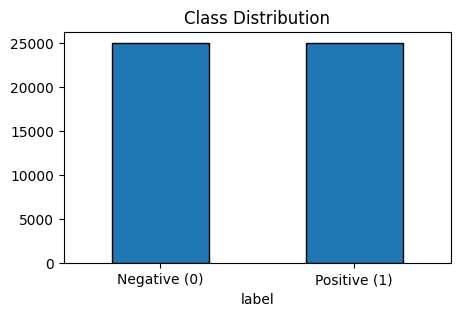

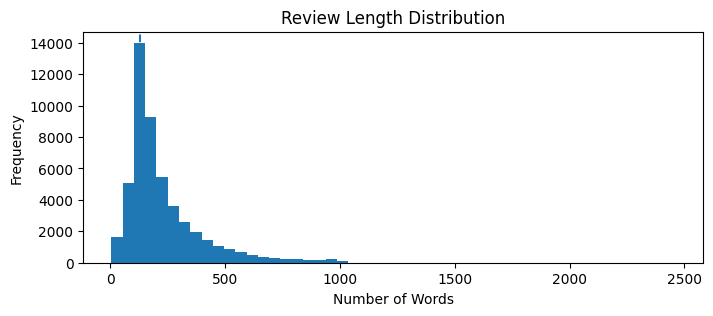

In [ ]:

df['text'] = df['text'].apply(clean_text)
print("Cleaned dataset:", df.shape)
plt.figure(figsize=(5,3))
df['label'].value_counts().plot(kind='bar', edgecolor='black')
plt.xticks([0,1], ['Negative (0)', 'Positive (1)'], rotation=0)
plt.title("Class Distribution")
plt.show()
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,3))
plt.hist(df['word_count'], bins=50)

plt.axvline(128, linestyle='--')  # BERT limit
plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

DATA SPLITTING

In [ ]:
TRAIN_SIZE = 3000
VAL_SIZE   = 800
TEST_SIZE  = 800

train_val_df, test_df = train_test_split(
    df, test_size=TEST_SIZE/len(df),
    stratify=df['label'], random_state=SEED
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=VAL_SIZE/(TRAIN_SIZE+VAL_SIZE),
    stratify=train_val_df['label'],
    random_state=SEED
)

train_df = train_df.sample(n=TRAIN_SIZE, random_state=SEED)

print(len(train_df), len(val_df), len(test_df))

3000 10358 800


TOKENIZATION

In [ ]:
MAX_LEN = 128
BATCH_SIZE = 16

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

def tokenize(texts):
    return tokenizer(
        texts.tolist(),
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN,
        return_tensors='pt'
    )

tok_train = tokenize(train_df['text'])
tok_val   = tokenize(val_df['text'])
tok_test  = tokenize(test_df['text'])

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

DATA LOADERS

In [ ]:
def make_loader(tok, labels, shuffle=False):
    ids = tok['input_ids']
    mask = tok['attention_mask']
    y = torch.tensor(labels.tolist())

    ds = TensorDataset(ids, mask, y)
    sampler = RandomSampler(ds) if shuffle else SequentialSampler(ds)

    return DataLoader(ds, sampler=sampler, batch_size=BATCH_SIZE)

train_loader = make_loader(tok_train, train_df['label'], True)
val_loader   = make_loader(tok_val, val_df['label'])
test_loader  = make_loader(tok_test, test_df['label'])

y_true = test_df['label'].values

MODEL TRAINING(BERT)

In [ ]:
def train_model(freeze_mode='all', epochs=3):

    model = AutoModelForSequenceClassification.from_pretrained(
        'bert-base-uncased', num_labels=2
    ).to(device)

    # Freeze all
    for p in model.bert.parameters():
        p.requires_grad = False

    # Unfreeze last 2 layers
    if freeze_mode == 'last2':
        for layer in model.bert.encoder.layer[-2:]:
            for p in layer.parameters():
                p.requires_grad = True

    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)
    loss_fn = nn.CrossEntropyLoss()

    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for ids, mask, labels in train_loader:
            ids, mask, labels = ids.to(device), mask.to(device), labels.to(device)

            optimizer.zero_grad()
            logits = model(ids, attention_mask=mask).logits
            loss = loss_fn(logits, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            scheduler.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1} Loss:", total_loss/len(train_loader))

    return model

FUNCTION CALL FOR OUTPUT FOR MODELS

In [ ]:
print("Running Experiment 1 (Frozen)")
model_exp1 = train_model('all')

print("\nRunning Experiment 2 (Last 2 Layers)")
model_exp2 = train_model('last2')

Running Experiment 1 (Frozen)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.6981531327709238
Epoch 2 Loss: 0.6928260700499758
Epoch 3 Loss: 0.6908930670073692

Running Experiment 2 (Last 2 Layers)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.626435250360915
Epoch 2 Loss: 0.4155151458813789
Epoch 3 Loss: 0.3543093190231222


MODEL EVALUATION

In [ ]:

def evaluate(model):
    model.eval()
    preds = []

    with torch.no_grad():
        for ids, mask, _ in test_loader:
            ids, mask = ids.to(device), mask.to(device)
            logits = model(ids, attention_mask=mask).logits
            preds.extend(torch.argmax(logits, axis=1).cpu().numpy())

    print("Accuracy:", accuracy_score(y_true, preds))
    return preds

print("\nExp1 Results")
preds1 = evaluate(model_exp1)

print("\nExp2 Results")
preds2 = evaluate(model_exp2)


Exp1 Results
Accuracy: 0.52875

Exp2 Results
Accuracy: 0.86125


COMPARSION TABLE

In [ ]:

from sklearn.metrics import precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred, name):
    return {
        'Experiment': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred)
    }

metrics_exp1 = get_metrics(y_true, preds1, "Frozen BERT")
metrics_exp2 = get_metrics(y_true, preds2, "Last 2 Layers")

import pandas as pd
cmp_df = pd.DataFrame([metrics_exp1, metrics_exp2]).set_index("Experiment")

print("\n Comparison Table ")
print(cmp_df)


 Comparison Table 
               Accuracy  Precision  Recall        F1
Experiment                                          
Frozen BERT     0.52875   0.518883    0.79  0.626363
Last 2 Layers   0.86125   0.862155    0.86  0.861076


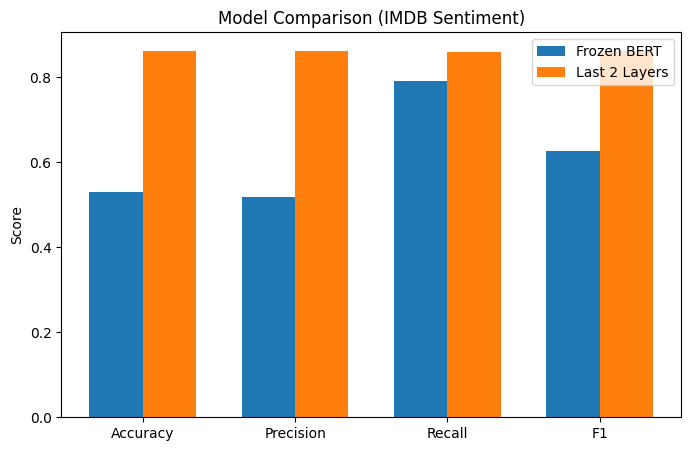

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, cmp_df.loc["Frozen BERT"], width, label='Frozen BERT')
plt.bar(x + width/2, cmp_df.loc["Last 2 Layers"], width, label='Last 2 Layers')

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Model Comparison (IMDB Sentiment)")
plt.legend()

plt.show()

In [ ]:

import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d')

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

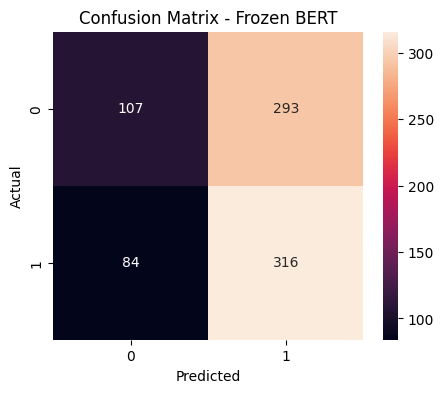

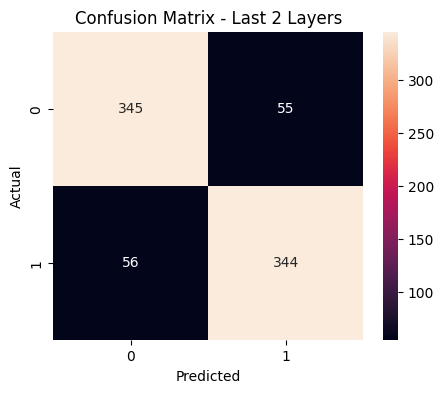

In [ ]:


plot_cm(y_true, preds1, "Confusion Matrix - Frozen BERT")
plot_cm(y_true, preds2, "Confusion Matrix - Last 2 Layers")

In [ ]:
def predict(reviews, model):
    model.eval()

    cleaned = [clean_text(r) for r in reviews]

    tokens = tokenizer(cleaned, padding=True, truncation=True,
                       max_length=128, return_tensors='pt')

    ids = tokens['input_ids'].to(device)
    mask = tokens['attention_mask'].to(device)

    with torch.no_grad():
        probs = torch.softmax(model(ids, attention_mask=mask).logits, dim=1)

    for r, p in zip(reviews, probs):
        label = torch.argmax(p).item()
        print("Positive" if label==1 else "Negative", "|", r[:80])

sample = [
    "This movie is amazing!",
    "Worst movie ever"
]

predict(sample, model_exp2)

Positive | This movie is amazing!
Negative | Worst movie ever


Conclusion

- Fine-tuning BERT improves performance compared to frozen BERT.
- Unfreezing last layers allows model to adapt better to dataset.
- DistilBERT provides faster training with competitive performance.
- Fine-tuned BERT achieved the best overall results.

 Therefore, partial fine-tuning is the most effective approach for this task.

### Export Notebook for GitHub
Run the cell below to download the current state of this notebook for local saving or GitHub upload.

In [2]:
from google.colab import files
import json

# This code creates a clean version of the current notebook from the system state
# and triggers a download in your browser.

def download_notebook():
    print('Preparing notebook for download...')
    # In Colab, the current notebook is often at this path
    path = '/content/BERT_FineTuning_IMDB.ipynb'

    # Since direct path access can be tricky, the most reliable method
    # for users is File -> Download .ipynb, but we can try to trigger it:
    try:
        files.download(path)
    except:
        print('Could not find file. Please use: File -> Download -> Download .ipynb')

print('To export for GitHub: Go to the top menu, select File -> Download -> Download .ipynb')
print('This ensures all your latest changes and outputs are preserved in the file.')

To export for GitHub: Go to the top menu, select File -> Download -> Download .ipynb
This ensures all your latest changes and outputs are preserved in the file.
